In [ ]:
# تثبيت Kaggle API إذا لم تكن مثبتة
!pip install kaggle

# تحميل مفتاح API الخاص بك إلى Colab
from google.colab import files
files.upload()  # قم بتحميل ملف kaggle.json هنا

# إنشاء مجلد لكاجل ونقل مفتاح API إليه
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json  # تأمين الملف

# تحميل البيانات من Kaggle
!kaggle datasets download -d mkechinov/ecommerce-behavior-data-from-multi-category-store

# فك ضغط الملف
!unzip ecommerce-behavior-data-from-multi-category-store.zip


Saving kaggle (3).json to kaggle (3).json
mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store
License(s): copyright-authors
100% 4.28G/4.29G [00:43<00:00, 105MB/s]
100% 4.29G/4.29G [00:43<00:00, 105MB/s]
Archive:  ecommerce-behavior-data-from-multi-category-store.zip
  inflating: 2019-Nov.csv            
  inflating: 2019-Oct.csv            


In [ ]:
import os

file_path = "2019-Nov.csv"  # اسم الملف

# الحصول على حجم الملف بالبايت
file_size = os.path.getsize(file_path)

# تحويل الحجم إلى ميغابايت أو غيغابايت لسهولة القراءة
file_size_mb = file_size / (1024 * 1024)  # تحويل إلى MB
file_size_gb = file_size / (1024 * 1024 * 1024)  # تحويل إلى GB

print(f"حجم الملف: {file_size_mb:.2f} MB ({file_size_gb:.2f} GB)")


حجم الملف: 8589.52 MB (8.39 GB)


In [ ]:
import os

file_path = "2019-Oct.csv"  # اسم الملف

# الحصول على حجم الملف بالبايت
file_size = os.path.getsize(file_path)

# تحويل الحجم إلى ميغابايت أو غيغابايت لسهولة القراءة
file_size_mb = file_size / (1024 * 1024)  # تحويل إلى MB
file_size_gb = file_size / (1024 * 1024 * 1024)  # تحويل إلى GB

print(f"حجم الملف: {file_size_mb:.2f} MB ({file_size_gb:.2f} GB)")


حجم الملف: 5406.01 MB (5.28 GB)


In [ ]:
import pandas as pd

# تحديد حجم كل جزء عند القراءة
chunksize = 100000

# إنشاء DataFrame فارغ لتخزين النتائج النهائية
cleaned_data = []

# تحميل البيانات على شكل أجزاء ومعالجتها
df_chunks = pd.read_csv("2019-Nov.csv", chunksize=chunksize)

# قراءة الأجزاء واحدًا تلو الآخر ومعالجتها
for chunk in df_chunks:
    # تحويل العمود event_time إلى datetime
    chunk['event_time'] = pd.to_datetime(chunk['event_time'], errors='coerce')

    # حذف القيم المفقودة
    chunk.dropna(inplace=True)

    # إزالة التكرارات
    chunk.drop_duplicates(inplace=True)

    # إزالة الأسعار غير المنطقية
    chunk = chunk[chunk['price'] > 0]

    # إضافة الجزء المنظف إلى القائمة
    cleaned_data.append(chunk)

# دمج جميع الأجزاء في DataFrame نهائي
df = pd.concat(cleaned_data, ignore_index=True)

# عرض أول 5 صفوف من البيانات النهائية
print(df.head())

# حفظ البيانات النظيفة إلى ملف جديد
df.to_csv("cleaned_data.csv", index=False)
print("✅ تم تنظيف البيانات وحفظها في cleaned_data.csv")


                 event_time event_type  product_id          category_id  \
0 2019-11-01 00:00:00+00:00       view     1003461  2053013555631882655   
1 2019-11-01 00:00:00+00:00       view     5000088  2053013566100866035   
2 2019-11-01 00:00:01+00:00       view     3601530  2053013563810775923   
3 2019-11-01 00:00:01+00:00       view     1004775  2053013555631882655   
4 2019-11-01 00:00:01+00:00       view     1306894  2053013558920217191   

               category_code   brand   price    user_id  \
0     electronics.smartphone  xiaomi  489.07  520088904   
1  appliances.sewing_machine  janome  293.65  530496790   
2  appliances.kitchen.washer      lg  712.87  518085591   
3     electronics.smartphone  xiaomi  183.27  558856683   
4         computers.notebook      hp  360.09  520772685   

                           user_session  
0  4d3b30da-a5e4-49df-b1a8-ba5943f1dd33  
1  8e5f4f83-366c-4f70-860e-ca7417414283  
2  3bfb58cd-7892-48cc-8020-2f17e6de6e7f  
3  313628f1-68b8-460d-84f6

In [ ]:
# معرفة حجم البيانات (عدد الصفوف والأعمدة)
print(f"عدد الصفوف والأعمدة: {df.shape}")

# معرفة أنواع البيانات
print(df.dtypes)

# عرض القيم الفريدة في عمود 'event_type'
print(df['event_type'].unique())

# عرض الإحصائيات الأساسية
print(df.describe())

عدد الصفوف والأعمدة: (42018772, 9)
event_time       datetime64[ns, UTC]
event_type                    object
product_id                     int64
category_id                    int64
category_code                 object
brand                         object
price                        float64
user_id                        int64
user_session                  object
dtype: object
['view' 'cart' 'purchase']
         product_id   category_id         price       user_id
count  4.201877e+07  4.201877e+07  4.201877e+07  4.201877e+07
mean   7.074908e+06  2.056195e+18  3.602615e+02  5.389891e+08
std    1.410199e+07  1.735717e+16  3.834009e+02  2.291416e+07
min    1.000365e+06  2.053014e+18  7.700000e-01  2.951588e+07
25%    1.005100e+06  2.053014e+18  1.091400e+02  5.165798e+08
50%    1.801901e+06  2.053014e+18  2.187700e+02  5.356418e+08
75%    5.100718e+06  2.053014e+18  4.661400e+02  5.618268e+08
max    1.000284e+08  2.187708e+18  2.574070e+03  5.799699e+08


In [ ]:
import os

file_path = "cleaned_data.csv"  # اسم الملف

# الحصول على حجم الملف بالبايت
file_size = os.path.getsize(file_path)

# تحويل الحجم إلى ميغابايت أو غيغابايت لسهولة القراءة
file_size_mb = file_size / (1024 * 1024)  # تحويل إلى MB
file_size_gb = file_size / (1024 * 1024 * 1024)  # تحويل إلى GB

print(f"حجم الملف: {file_size_mb:.2f} MB ({file_size_gb:.2f} GB)")


حجم الملف: 5734.99 MB (5.60 GB)


In [ ]:
import pandas as pd

# تحديد حجم كل جزء
chunksize = 100000

# ملف البيانات المنظف
input_file = "cleaned_data.csv"

# متغير لتخزين عدد العمليات لكل نوع
event_counts = {}

# قراءة البيانات جزءًا جزءًا
df_chunks = pd.read_csv(input_file, chunksize=chunksize)

for chunk in df_chunks:
    counts = chunk['event_type'].value_counts().to_dict()

    # جمع القيم مع القيم السابقة
    for key, value in counts.items():
        event_counts[key] = event_counts.get(key, 0) + value

# عرض النتيجة النهائية
print("📊 عدد العمليات حسب نوع النشاط:")
for event, count in event_counts.items():
    print(f"{event}: {count}")


📊 عدد العمليات حسب نوع النشاط:
view: 39314217
purchase: 659251
cart: 2045304


In [ ]:
import pandas as pd

# تحديد حجم كل جزء
chunksize = 100000

# ملف البيانات المنظف
input_file = "cleaned_data.csv"

# متغير لتخزين عدد المشتريات حسب الساعة
purchase_counts = {}

# قراءة البيانات جزءًا جزءًا
df_chunks = pd.read_csv(input_file, chunksize=chunksize)

for chunk in df_chunks:
    chunk['event_time'] = pd.to_datetime(chunk['event_time'])
    chunk['hour'] = chunk['event_time'].dt.hour

    # حساب عدد عمليات الشراء لكل ساعة
    counts = chunk[chunk['event_type'] == 'purchase']['hour'].value_counts().to_dict()

    # جمع القيم مع القيم السابقة
    for hour, count in counts.items():
        purchase_counts[hour] = purchase_counts.get(hour, 0) + count

# عرض النتائج
sorted_hours = sorted(purchase_counts.keys())
for hour in sorted_hours:
    print(f"الساعة {hour}: {purchase_counts[hour]} عملية شراء")


<ipython-input-8-524793171a9e>:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  chunk['event_time'] = pd.to_datetime(chunk['event_time'])


الساعة 0: 1990 عملية شراء
الساعة 1: 2879 عملية شراء
الساعة 2: 7349 عملية شراء
الساعة 3: 17890 عملية شراء
الساعة 4: 30681 عملية شراء
الساعة 5: 37588 عملية شراء
الساعة 6: 40918 عملية شراء
الساعة 7: 41912 عملية شراء
الساعة 8: 47307 عملية شراء
الساعة 9: 52140 عملية شراء
الساعة 10: 50496 عملية شراء
الساعة 11: 47219 عملية شراء
الساعة 12: 44970 عملية شراء
الساعة 13: 43776 عملية شراء
الساعة 14: 43247 عملية شراء
الساعة 15: 37595 عملية شراء
الساعة 16: 32714 عملية شراء
الساعة 17: 31533 عملية شراء
الساعة 18: 16994 عملية شراء
الساعة 19: 12406 عملية شراء
الساعة 20: 7497 عملية شراء
الساعة 21: 4747 عملية شراء
الساعة 22: 3312 عملية شراء
الساعة 23: 2091 عملية شراء


In [ ]:
import pandas as pd

# تحديد حجم كل جزء
chunksize = 100000

# ملف البيانات المنظف
input_file = "cleaned_data.csv"

# متغير لتخزين عدد مرات شراء كل منتج
product_counts = {}

# قراءة البيانات جزءًا جزءًا
df_chunks = pd.read_csv(input_file, chunksize=chunksize)

for chunk in df_chunks:
    counts = chunk[chunk['event_type'] == 'purchase']['product_id'].value_counts().to_dict()

    # جمع القيم مع القيم السابقة
    for product, count in counts.items():
        product_counts[product] = product_counts.get(product, 0) + count

# عرض أعلى 10 منتجات مبيعًا
top_products = sorted(product_counts.items(), key=lambda x: x[1], reverse=True)[:10]
print("📊 أكثر 10 منتجات مبيعًا:")
for product, count in top_products:
    print(f"المنتج {product}: {count} عملية شراء")


📊 أكثر 10 منتجات مبيعًا:
المنتج 1004856: 32321 عملية شراء
المنتج 1004767: 22613 عملية شراء
المنتج 1005115: 22244 عملية شراء
المنتج 4804056: 17800 عملية شراء
المنتج 1004833: 13486 عملية شراء
المنتج 1002544: 11678 عملية شراء
المنتج 1004870: 10673 عملية شراء
المنتج 1005100: 10132 عملية شراء
المنتج 1004249: 8881 عملية شراء
المنتج 1005105: 8483 عملية شراء


In [ ]:
import pandas as pd

# تحديد حجم كل جزء
chunksize = 100000

# ملف البيانات المنظف
input_file = "cleaned_data.csv"


# متغير لتخزين عدد مرات شراء كل فئة
category_counts = {}

# قراءة البيانات جزءًا جزءًا
df_chunks = pd.read_csv(input_file, chunksize=chunksize)

for chunk in df_chunks:
    counts = chunk[chunk['event_type'] == 'purchase']['category_code'].value_counts().to_dict()

    # جمع القيم مع القيم السابقة
    for category, count in counts.items():
        category_counts[category] = category_counts.get(category, 0) + count

# عرض أعلى 10 فئات مبيعًا
top_categories = sorted(category_counts.items(), key=lambda x: x[1], reverse=True)[:10]
print("📊 أكثر 10 فئات مبيعًا:")
for category, count in top_categories:
    print(f"الفئة {category}: {count} عملية شراء")


📊 أكثر 10 فئات مبيعًا:
الفئة electronics.smartphone: 382491 عملية شراء
الفئة electronics.audio.headphone: 40742 عملية شراء
الفئة electronics.video.tv: 30177 عملية شراء
الفئة electronics.clocks: 21426 عملية شراء
الفئة appliances.kitchen.washer: 19679 عملية شراء
الفئة computers.notebook: 18323 عملية شراء
الفئة appliances.environment.vacuum: 18122 عملية شراء
الفئة appliances.kitchen.refrigerators: 10420 عملية شراء
الفئة apparel.shoes: 8768 عملية شراء
الفئة electronics.tablet: 6123 عملية شراء


In [ ]:
import pandas as pd

# تحديد حجم كل جزء
chunksize = 100000

# ملف البيانات المنظف
input_file = "cleaned_data.csv"

# متغير لتخزين عدد العمليات لكل مستخدم
user_activity = {}

# قراءة البيانات جزءًا جزءًا
df_chunks = pd.read_csv(input_file, chunksize=chunksize)

for chunk in df_chunks:
    counts = chunk['user_id'].value_counts().to_dict()

    # جمع القيم مع القيم السابقة
    for user, count in counts.items():
        user_activity[user] = user_activity.get(user, 0) + count

# تحويل النتائج إلى DataFrame
df_users = pd.DataFrame(list(user_activity.items()), columns=['user_id', 'activity_count'])

# عرض أول 5 صفوف
print(df_users.head())


     user_id  activity_count
0  523673770             126
1  561394540              94
2  534949460             220
3  566291403             166
4  515784126             447


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


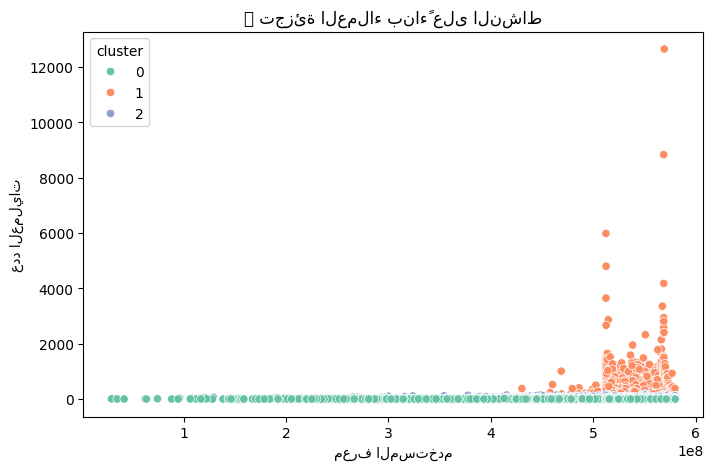

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# تطبيق K-Means لتحديد 3 مجموعات
kmeans = KMeans(n_clusters=3, random_state=42)
df_users['cluster'] = kmeans.fit_predict(df_users[['activity_count']])

# عرض توزيع المجموعات
plt.figure(figsize=(8,5))
sns.scatterplot(x=df_users['user_id'], y=df_users['activity_count'], hue=df_users['cluster'], palette="Set2")
plt.title("📊 تجزئة العملاء بناءً على النشاط")
plt.xlabel("معرف المستخدم")
plt.ylabel("عدد العمليات")
plt.show()


In [ ]:
import os

file_path = "cleaned_data.csv"  # اسم الملف

# الحصول على حجم الملف بالبايت
file_size = os.path.getsize(file_path)

# تحويل الحجم إلى ميغابايت أو غيغابايت لسهولة القراءة
file_size_mb = file_size / (1024 * 1024)  # تحويل إلى MB
file_size_gb = file_size / (1024 * 1024 * 1024)  # تحويل إلى GB

print(f"حجم الملف: {file_size_mb:.2f} MB ({file_size_gb:.2f} GB)")


حجم الملف: 5734.99 MB (5.60 GB)


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd


sample_df = pd.read_csv("cleaned_data.csv", nrows=1000)


size_per_row = sample_df.memory_usage(deep=True).sum() / len(sample_df)

rows_1gb = int((1 * 1024 * 1024 * 1024) / size_per_row)

print(f"عدد الصفوف التقريبي للحصول على 1GB: {rows_1gb}")


عدد الصفوف التقريبي للحصول على 1GB: 2617273


In [ ]:
save_path = "/content/drive/My Drive/cleaned_data_100_rows.xlsx"

chunk = pd.read_csv("cleaned_data.csv", nrows=100)  # حفظ 10000 صف فقط
chunk.to_csv(save_path, index=False)

print("✅ تم استخراج وحفظ 10,000 صف من البيانات في Google Drive")


✅ تم استخراج وحفظ 10,000 صف من البيانات في Google Drive


In [ ]:
save_path = "/content/drive/My Drive/cleaned_data_100_rows.csv"

chunk = pd.read_csv("cleaned_data.csv", nrows=100)  # حفظ 10000 صف فقط
chunk.to_csv(save_path, index=False)

print("✅ تم استخراج وحفظ 10,000 صف من البيانات في Google Drive")

✅ تم استخراج وحفظ 10,000 صف من البيانات في Google Drive


In [ ]:
save_path = "/content/drive/My Drive/cleaned_data_500MB.csv"

chunk = pd.read_csv("cleaned_data.csv", nrows=rows_1gb // 1000)  # حفظ نصف عدد الصفوف
chunk.to_csv(save_path, index=False)

print("✅ تم استخراج وحفظ 500MB من البيانات في Google Drive")


✅ تم استخراج وحفظ 500MB من البيانات في Google Drive


📊 بيانات نشاط العملاء:
    user_id  total_purchases  total_carts  total_views  total_spent
0  29515875                0            0            7       967.49
1  31198833                0            0           19      6398.43
2  34916060                0            0            1       295.94
3  41798457                0            0            1       945.97
4  62336140                0            0            6       575.83

📊 بيانات العملاء مع المجموعات:
    user_id  total_purchases  total_carts  total_views  total_spent  cluster
0  29515875                0            0            7       967.49        1
1  31198833                0            0           19      6398.43        1
2  34916060                0            0            1       295.94        1
3  41798457                0            0            1       945.97        1
4  62336140                0            0            6       575.83        1


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


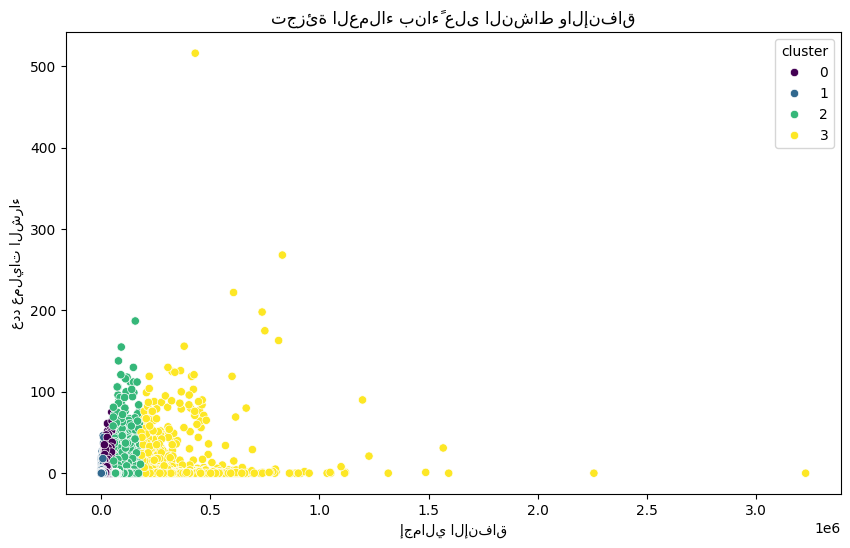


📊 تحليل المجموعات:
   cluster  avg_purchases  avg_carts   avg_views      avg_spent    count
0        0       0.900888   2.978529   55.661508   24743.354779   230215
1        1       0.142751   0.426904    8.069161    2382.970757  2599115
2        2       2.157131   6.935245  146.770954   83788.602548    31426
3        3       5.983479  14.723268  419.917852  282102.015443     2179


In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 1. تحميل البيانات المنظفة
cleaned_data = pd.read_csv("cleaned_data.csv")

# 2. تحضير البيانات: إنشاء متغيرات رقمية تعكس نشاط العملاء
customer_activity = cleaned_data.groupby('user_id').agg(
    total_purchases=('event_type', lambda x: (x == 'purchase').sum()),  # عدد عمليات الشراء
    total_carts=('event_type', lambda x: (x == 'cart').sum()),         # عدد مرات إضافة إلى السلة
    total_views=('event_type', lambda x: (x == 'view').sum()),         # عدد مرات المشاهدة
    total_spent=('price', 'sum')                                       # إجمالي الإنفاق
).reset_index()

# عرض أول 5 صفوف من البيانات الجديدة
print("📊 بيانات نشاط العملاء:")
print(customer_activity.head())

# 3. تطبيق خوارزمية K-Means Clustering
# نختار عدد المجموعات (مثلاً 4)
kmeans = KMeans(n_clusters=4, random_state=42)

# نطبق K-Means على البيانات
customer_activity['cluster'] = kmeans.fit_predict(customer_activity[['total_purchases', 'total_carts', 'total_views', 'total_spent']])

# عرض أول 5 صفوف مع المجموعات المحددة
print("\n📊 بيانات العملاء مع المجموعات:")
print(customer_activity.head())

# 4. تصور النتائج
# رسم مخطط scatter plot لتوزيع العملاء بناءً على الإنفاق وعدد المشتريات
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_spent', y='total_purchases', hue='cluster', data=customer_activity, palette='viridis')
plt.title('تجزئة العملاء بناءً على النشاط والإنفاق')
plt.xlabel('إجمالي الإنفاق')
plt.ylabel('عدد عمليات الشراء')
plt.show()

# 5. تحليل المجموعات
# حساب متوسطات النشاط لكل مجموعة
cluster_summary = customer_activity.groupby('cluster').agg(
    avg_purchases=('total_purchases', 'mean'),
    avg_carts=('total_carts', 'mean'),
    avg_views=('total_views', 'mean'),
    avg_spent=('total_spent', 'mean'),
    count=('user_id', 'count')
).reset_index()

print("\n📊 تحليل المجموعات:")
print(cluster_summary)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. تحميل البيانات المنظفة
cleaned_data = pd.read_csv("cleaned_data.csv")

# 2. تحضير البيانات: إنشاء متغيرات رقمية تعكس نشاط العملاء
customer_activity = cleaned_data.groupby('user_id').agg(
    total_purchases=('event_type', lambda x: (x == 'purchase').sum()),  # عدد عمليات الشراء
    total_carts=('event_type', lambda x: (x == 'cart').sum()),         # عدد مرات إضافة إلى السلة
    total_views=('event_type', lambda x: (x == 'view').sum()),         # عدد مرات المشاهدة
    total_spent=('price', 'sum')                                       # إجمالي الإنفاق
).reset_index()

# 3. تحديد المتغير الهدف (Target Variable)
# ننشئ متغيرًا ثنائيًا (1 إذا قام العميل بعملية شراء، 0 إذا لم يقم بذلك)
customer_activity['has_purchased'] = customer_activity['total_purchases'].apply(lambda x: 1 if x > 0 else 0)

# 4. تحديد المتغيرات المستقلة (Features) والتابعة (Target)
X = customer_activity[['total_carts', 'total_views', 'total_spent']]  # الميزات (Features)
y = customer_activity['has_purchased']  # الهدف (Target)

# 5. تقسيم البيانات إلى مجموعتي تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. بناء النموذج (نستخدم RandomForestClassifier)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 7. التنبؤ على مجموعة الاختبار
y_pred = model.predict(X_test)

# 8. تقييم النموذج
accuracy = accuracy_score(y_test, y_pred)
print(f"دقة النموذج: {accuracy:.2f}")

# عرض تقرير التصنيف
print("\n📊 تقرير التصنيف:")
print(classification_report(y_test, y_pred))

دقة النموذج: 0.90

📊 تقرير التصنيف:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94    506468
           1       0.56      0.55      0.56     66119

    accuracy                           0.90    572587
   macro avg       0.75      0.75      0.75    572587
weighted avg       0.90      0.90      0.90    572587



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. تحميل البيانات المنظفة
cleaned_data = pd.read_csv("cleaned_data.csv")

# 2. تحضير البيانات: إنشاء متغيرات رقمية تعكس نشاط العملاء
customer_activity = cleaned_data.groupby('user_id').agg(
    total_purchases=('event_type', lambda x: (x == 'purchase').sum()),  # عدد عمليات الشراء
    total_carts=('event_type', lambda x: (x == 'cart').sum()),         # عدد مرات إضافة إلى السلة
    total_views=('event_type', lambda x: (x == 'view').sum()),         # عدد مرات المشاهدة
    total_spent=('price', 'sum')                                       # إجمالي الإنفاق
).reset_index()

# 3. تحديد المتغيرات المستقلة (Features) والتابعة (Target)
X = customer_activity[['total_carts', 'total_views', 'total_spent']]  # الميزات (Features)
y = customer_activity['total_purchases']  # الهدف (Target)

# 4. تقسيم البيانات إلى مجموعتي تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. تجربة خوارزميات مختلفة وحساب RMSE لكل منها
models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42)
}

for name, model in models.items():
    # تدريب النموذج
    model.fit(X_train, y_train)

    # التنبؤ على مجموعة الاختبار
    y_pred = model.predict(X_test)

    # حساب RMSE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"📊 RMSE لخوارزمية {name}: {rmse:.2f}")

📊 RMSE لخوارزمية Random Forest: 0.82
📊 RMSE لخوارزمية Gradient Boosting: 0.78
📊 RMSE لخوارزمية XGBoost: 0.80
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.099372 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 572
[LightGBM] [Info] Number of data points in the train set: 2290348, number of used features: 3
[LightGBM] [Info] Start training from score 0.229984
📊 RMSE لخوارزمية LightGBM: 0.79
